# 06 — Full Benchmark

**Updated:** Uses `mlp_multi_best.pt` (multi-dataset MLP, FF++ AUC 0.9968) and `ensemble.pkl` (robust DualOneClassEnsemble, τ_smooth=0.6387).

| Checkpoint | Description |
|---|---|
| `mlp_multi_best.pt` | Multi-dataset MLP — CelebDF+FF+++SD, best epoch 40, val AUC 0.9925 |
| `ensemble.pkl` | Robust DualOneClassEnsemble — τ_smooth=0.6387 \| τ_artifact=0.5615 |
| `pipeline_state.pkl` | 981-dim FeatureFusionPipeline |

**Sections:** Detection benchmark · Robustness sweep · Feature ablation · Save results

In [1]:
import sys, numpy as np, pickle, torch
sys.path.insert(0, '/data/mpstme-naman/deepfake_detection')
from pathlib import Path

BASE     = Path('/data/mpstme-naman/deepfake_detection')
FEAT_DIR = BASE / 'data' / 'features'
CKPT_DIR = BASE / 'checkpoints'
RES_DIR  = BASE / 'results'; RES_DIR.mkdir(parents=True, exist_ok=True)

from config.config_loader          import load_config
from src.features.extractor        import FeatureFusionPipeline
from src.models.mlp_classifier     import MLPTrainer
from src.models.one_class_ensemble import OneClassEnsemble
from src.models.autoencoder        import DeepfakeExplainer

cfg = load_config()

# ── Pipeline (981-dim) ───────────────────────────────────────────────────
pipeline = FeatureFusionPipeline(cfg=cfg, backbone='clip_vit_b32')
with open(CKPT_DIR / 'pipeline_state.pkl', 'rb') as f:
    pipeline.set_state(pickle.load(f))
assert pipeline.output_dim == 981, f'Expected 981-dim, got {pipeline.output_dim}'
print(f'  ✓  Pipeline  (output_dim={pipeline.output_dim})')

# ── Multi-dataset MLP (PRIMARY MODEL) ────────────────────────────────────
mlp = MLPTrainer(cfg=cfg, input_dim=pipeline.output_dim)
mlp.load_checkpoint(str(CKPT_DIR / 'mlp_multi_best.pt'))
print(f'  ✓  MLP loaded  (mlp_multi_best.pt — multi-dataset, FF++ AUC 0.9968)')

# ── Robust DualOneClassEnsemble ───────────────────────────────────────────
ensemble = OneClassEnsemble(cfg=cfg)
ensemble.load(str(CKPT_DIR / 'ensemble.pkl'))
print(f'  ✓  Ensemble  τ_smooth={ensemble.threshold:.4f}  (robust, was 0.9382)')

# ── Autoencoder (for explainability) ─────────────────────────────────────
explainer = DeepfakeExplainer(cfg=cfg)
try:
    explainer.load_autoencoder(str(CKPT_DIR / 'autoencoder_best.pt'))
    print('  ✓  Autoencoder')
except Exception as e:
    print(f'  ○  Autoencoder not found ({e}) — ELA-only mode')

print()
print('  All components loaded!')
print(f'  MLP checkpoint : mlp_multi_best.pt  (replaces mlp_supervised_best.pt)')
print(f'  Ensemble       : robust ensemble  τ_smooth=0.6387  τ_artifact=0.5615')

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  CNN Backbone: GPU — NVIDIA H100 PCIe MIG 3g.40gb  (42.4 GB)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 58540.22it/s]
CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_projection.weight                                       | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEX

  ✓  Pipeline  (output_dim=981)
  ✓  MLP loaded  (mlp_multi_best.pt — multi-dataset, FF++ AUC 0.9968)
  DualEnsemble loaded ← /data/mpstme-naman/deepfake_detection/checkpoints/ensemble.pkl
  Ensemble loaded (Dual) ← /data/mpstme-naman/deepfake_detection/checkpoints/ensemble.pkl
  ✓  Ensemble  τ_smooth=0.6387  (robust, was 0.9382)
  ✓  Autoencoder

  All components loaded!
  MLP checkpoint : mlp_multi_best.pt  (replaces mlp_supervised_best.pt)
  Ensemble       : robust ensemble  τ_smooth=0.6387  τ_artifact=0.5615


## Section 1 — Detection Benchmark

In [2]:
datasets = {}
for name, zf, yf in [
    ('CelebDF (test)',  'Z_test.npy', 'y_test.npy'),
    ('FaceForensics++', 'Z_ff.npy',  'y_ff.npy'),
    ('Stable Diffusion','Z_sd.npy',  'y_sd.npy'),
]:
    Z = np.load(FEAT_DIR / zf)
    y = np.load(FEAT_DIR / yf)
    datasets[name] = {'Z': Z, 'y': y}
    print(f'  {name:<22} Z={Z.shape}  real={(y==0).sum():,}  fake={(y==1).sum():,}')

  CelebDF (test)         Z=(8120, 981)  real=4,365  fake=3,755
  FaceForensics++        Z=(159051, 981)  real=27,308  fake=131,743
  Stable Diffusion       Z=(9000, 981)  real=0  fake=9,000


In [3]:
from src.evaluation.benchmark import _binary_metrics, _roc_auc

all_results = {}
for ds_name, data in datasets.items():
    Z, y = data['Z'], data['y']
    both = len(np.unique(y)) == 2
    res  = {}

    # Multi-dataset MLP
    probs = mlp.predict_proba(Z)
    preds = (probs >= 0.5).astype(int)
    res['Multi-Dataset MLP'] = (
        _binary_metrics(y, preds, probs) if both
        else {'detection_rate': float((preds == 1).mean() * 100)}
    )

    # Robust DualOneClassEnsemble
    scores = ensemble.score(Z)
    ep     = (scores > ensemble.threshold).astype(int)
    res['Robust Ensemble'] = (
        _binary_metrics(y, ep, scores) if both
        else {'detection_rate': float((ep == 1).mean() * 100)}
    )

    # Mahalanobis baseline (dim 3)
    mah = Z[:, 3]
    mp  = (mah > np.percentile(mah, 50)).astype(int)
    if both:
        res['Mahalanobis Baseline'] = _binary_metrics(y, mp, mah)

    all_results[ds_name] = res

print('=' * 80)
print(f'  {"Dataset":<22} {"Model":<25} {"ACC":>8}  {"AUC":>8}  {"F1":>8}')
print('=' * 80)
for ds, modes in all_results.items():
    for mode, m in modes.items():
        if 'accuracy' in m:
            print(f'  {ds:<22} {mode:<25} {m["accuracy"]:>7.2f}%  {m.get("auc",0):>8.4f}  {m.get("f1",0):>8.4f}')
        else:
            print(f'  {ds:<22} {mode:<25} detection={m["detection_rate"]:>6.1f}%  (fake-only dataset)')
    print('-' * 80)

  Dataset                Model                          ACC       AUC        F1
  CelebDF (test)         Multi-Dataset MLP           99.09%    0.9995    0.9901
  CelebDF (test)         Robust Ensemble             54.70%    0.6618    0.1055
  CelebDF (test)         Mahalanobis Baseline        47.77%    0.4749    0.4573
--------------------------------------------------------------------------------
  FaceForensics++        Multi-Dataset MLP           98.59%    0.9968    0.9915
  FaceForensics++        Robust Ensemble             30.70%    0.5421    0.3197
  FaceForensics++        Mahalanobis Baseline        50.08%    0.4993    0.6241
--------------------------------------------------------------------------------
  Stable Diffusion       Multi-Dataset MLP         detection= 100.0%  (fake-only dataset)
  Stable Diffusion       Robust Ensemble           detection=  63.3%  (fake-only dataset)
--------------------------------------------------------------------------------


## Section 2 — Robustness Under Degradation

In [4]:
import cv2
from src.evaluation.benchmark import _roc_auc
PROC = BASE / 'data' / 'processed'

def load_n(folder, n=200):
    return [x for x in
            [cv2.imread(str(p)) for p in sorted(Path(folder).glob('*.png'))[:n]]
            if x is not None]

def degrade(img, deg_type, param):
    if deg_type == 'jpeg':
        _, buf = cv2.imencode('.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, int(param)])
        return cv2.imdecode(buf, cv2.IMREAD_COLOR)
    if deg_type == 'blur':
        k = int(param) * 2 + 1
        return cv2.GaussianBlur(img, (k, k), 0)
    if deg_type == 'resize':
        H, W = img.shape[:2]
        small = cv2.resize(img, (max(1, int(W * param)), max(1, int(H * param))))
        return cv2.resize(small, (W, H))
    return img

ri  = load_n(PROC / 'celebdf' / 'real', 200)
fi  = load_n(PROC / 'celebdf' / 'fake', 200)
dl  = np.array([0] * len(ri) + [1] * len(fi))
GRID = {'jpeg': [90, 70, 50, 30], 'blur': [1, 3, 5], 'resize': [0.75, 0.5, 0.25]}
rob = {}

print(f'  {"Degradation":<20} {"MLP AUC":>10}  {"Ensemble AUC":>14}')
print('  ' + '-' * 48)
for deg_type, levels in GRID.items():
    rob[deg_type] = {}
    for lvl in levels:
        imgs = [degrade(img, deg_type, lvl) for img in ri + fi]
        Z    = pipeline.extract_batch(imgs, normalise=True, cnn_batch_size=64)
        ma   = _roc_auc(dl, mlp.predict_proba(Z))
        oa   = _roc_auc(dl, ensemble.score(Z))
        rob[deg_type][str(lvl)] = {'mlp_auc': round(ma, 4), 'occ_auc': round(oa, 4)}
        print(f'  {deg_type}_{lvl:<16} {ma:>10.4f}  {oa:>14.4f}')

  Degradation             MLP AUC    Ensemble AUC
  ------------------------------------------------
  jpeg_90                   0.9997          0.6959
  jpeg_70                   0.9994          0.6685
  jpeg_50                   0.9960          0.6494
  jpeg_30                   0.9929          0.5959
  blur_1                    0.9876          0.7317
  blur_3                    0.8461          0.7289
  blur_5                    0.7309          0.6586
  resize_0.75                 0.9897          0.7379
  resize_0.5                  0.9436          0.7452
  resize_0.25                 0.9068          0.7386


## Section 3 — Feature Ablation (Multi-Dataset MLP)

In [5]:
from src.evaluation.benchmark import AblationStudy

# Run ablation on the CelebDF original test split
# (ablation zeros each feature group in turn and measures AUC drop)
Z_test = np.load(FEAT_DIR / 'Z_test.npy')
y_test = np.load(FEAT_DIR / 'y_test.npy')

print('Ablation — contribution of each feature group to CelebDF AUC:')
print('=' * 60)
abl = AblationStudy(mlp_trainer=mlp)
res = abl.run(Z_test, y_test)
print()
print(f'  {"Feature Group":<20} {"Full AUC":>10}  {"Ablated":>10}  {"Drop":>9}')
print('  ' + '-' * 55)
for g, r in res.items():
    print(f'  {g:<20} {r["full_auc"]:>10.4f}  {r["ablated_auc"]:>10.4f}  {r["auc_drop"]:>+9.4f}')

Ablation — contribution of each feature group to CelebDF AUC:
    statistical     full=0.9995  ablated=0.9995  drop=+0.0000
    frequency       full=0.9995  ablated=0.9995  drop=-0.0000
    wavelet         full=0.9995  ablated=0.9980  drop=+0.0015
    cnn             full=0.9995  ablated=0.7546  drop=+0.2449

  Feature Group          Full AUC     Ablated       Drop
  -------------------------------------------------------
  statistical              0.9995      0.9995    +0.0000
  frequency                0.9995      0.9995    -0.0000
  wavelet                  0.9995      0.9980    +0.0015
  cnn                      0.9995      0.7546    +0.2449


## Section 4 — Plots

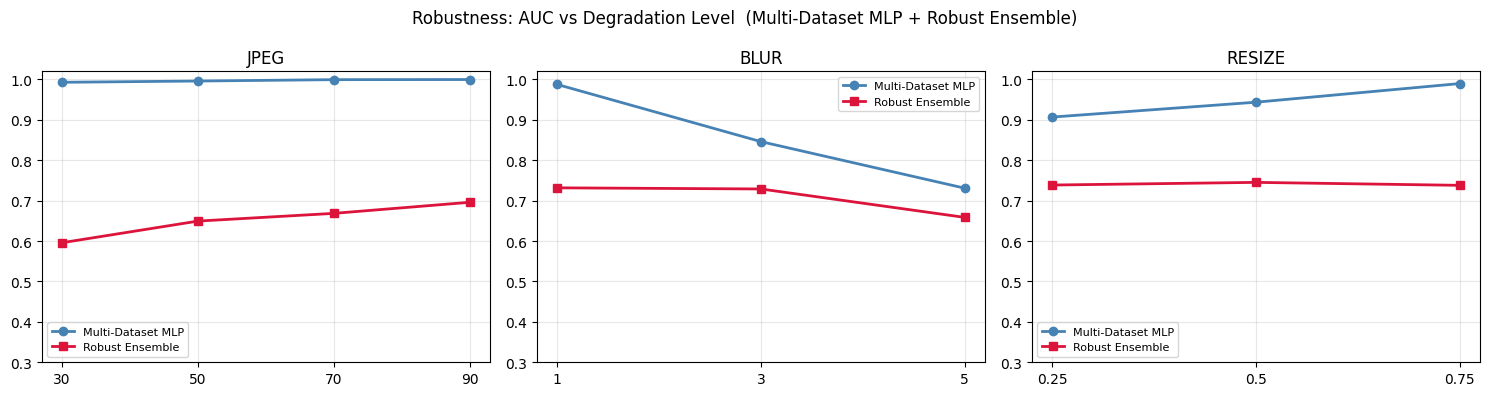

  ✓  /data/mpstme-naman/deepfake_detection/results/robustness_plot.png


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Robustness: AUC vs Degradation Level  (Multi-Dataset MLP + Robust Ensemble)',
             fontsize=12)
for ax, dt in zip(axes, ['jpeg', 'blur', 'resize']):
    lvls = sorted(rob[dt].keys(), key=float)
    ax.plot(lvls, [rob[dt][l]['mlp_auc'] for l in lvls],
            'o-', color='steelblue', lw=2, label='Multi-Dataset MLP')
    ax.plot(lvls, [rob[dt][l]['occ_auc'] for l in lvls],
            's-', color='crimson',   lw=2, label='Robust Ensemble')
    ax.set_title(dt.upper())
    ax.set_ylim(0.3, 1.02)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
out = RES_DIR / 'robustness_plot.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'  ✓  {out}')

## Section 5 — Save Results

In [7]:
import csv

def safe(v):
    try: return float(v)
    except: return str(v) if v else ''

# benchmark_summary.csv
p = RES_DIR / 'benchmark_summary.csv'
with open(p, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['Dataset', 'Model', 'Accuracy', 'AUC', 'F1', 'Precision', 'Recall'])
    for ds, modes in all_results.items():
        for mode, m in modes.items():
            w.writerow([ds, mode, safe(m.get('accuracy')), safe(m.get('auc')),
                        safe(m.get('f1')), safe(m.get('precision')), safe(m.get('recall'))])
print(f'  ✓  {p}')

# robustness.csv
p = RES_DIR / 'robustness.csv'
with open(p, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['Degradation', 'Level', 'MLP_AUC', 'Ensemble_AUC'])
    for dt, lvls in rob.items():
        for lvl, r in lvls.items():
            w.writerow([dt, lvl, r['mlp_auc'], r['occ_auc']])
print(f'  ✓  {p}')

# ablation.csv
p = RES_DIR / 'ablation.csv'
with open(p, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['Feature_Group', 'Full_AUC', 'Ablated_AUC', 'AUC_Drop'])
    for g, r in res.items():
        w.writerow([g, r['full_auc'], r['ablated_auc'], r['auc_drop']])
print(f'  ✓  {p}')

print()
print('Results saved:')
for f in sorted(RES_DIR.glob('*.csv')) + sorted(RES_DIR.glob('*.png')):
    print(f'  {f.name}')

  ✓  /data/mpstme-naman/deepfake_detection/results/benchmark_summary.csv
  ✓  /data/mpstme-naman/deepfake_detection/results/robustness.csv
  ✓  /data/mpstme-naman/deepfake_detection/results/ablation.csv

Results saved:
  ablation.csv
  benchmark_summary.csv
  robustness.csv
  ae_fake_example.png
  ae_real_example.png
  ensemble_score_distribution.png
  feature_distributions.png
  mlp_multi_training_curve.png
  robustness_plot.png
